# Data Collection

* Asset: S&P 500 Index (^GSPC)
* Frequency: Daily
* Sample period: January 1, 2015 – December 31, 2025
* Variable used: Daily adjusted closing price

In [1]:
from __future__ import annotations

!pip install arch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from arch import arch_model
from tqdm import tqdm

sns.set_theme(style='whitegrid')

START_DATE = '2015-01-01'
END_DATE = '2025-12-31'
DOWNLOAD_END_EXCLUSIVE = '2026-01-01'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 11.7 MB/s eta 0:00:00


In [2]:
try:
    import yfinance as yf
except ImportError as exc:
    raise ImportError("Install yfinance first (e.g., %pip install yfinance)") from exc

raw = yf.download('^GSPC', start=START_DATE, end=DOWNLOAD_END_EXCLUSIVE, progress=False, auto_adjust=False)

if raw.empty:
    raise ValueError('No data returned. Check internet access or ticker symbol.')

close = raw['Adj Close']
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

close = close.rename('close').dropna().loc[START_DATE:END_DATE].to_frame()
close.head()

,close
Date,
2015-01-02,2058.199951
2015-01-05,2020.579956
2015-01-06,2002.609985
2015-01-07,2025.900024
2015-01-08,2062.139893


In [3]:
close.tail()

,close
Date,
2025-12-24,6932.049805
2025-12-26,6929.939941
2025-12-29,6905.740234
2025-12-30,6896.240234
2025-12-31,6845.500000


In [4]:
# Transform close prices into daily log returns
close['log_return'] = np.log(close['close'] / close['close'].shift(1))
log_returns = close['log_return'].dropna()

log_returns.describe()

,log_return
count,2765.000000
mean,0.000435
std,0.011312
min,-0.127652
25%,-0.003781
50%,0.000698
75%,0.005741
max,0.090895


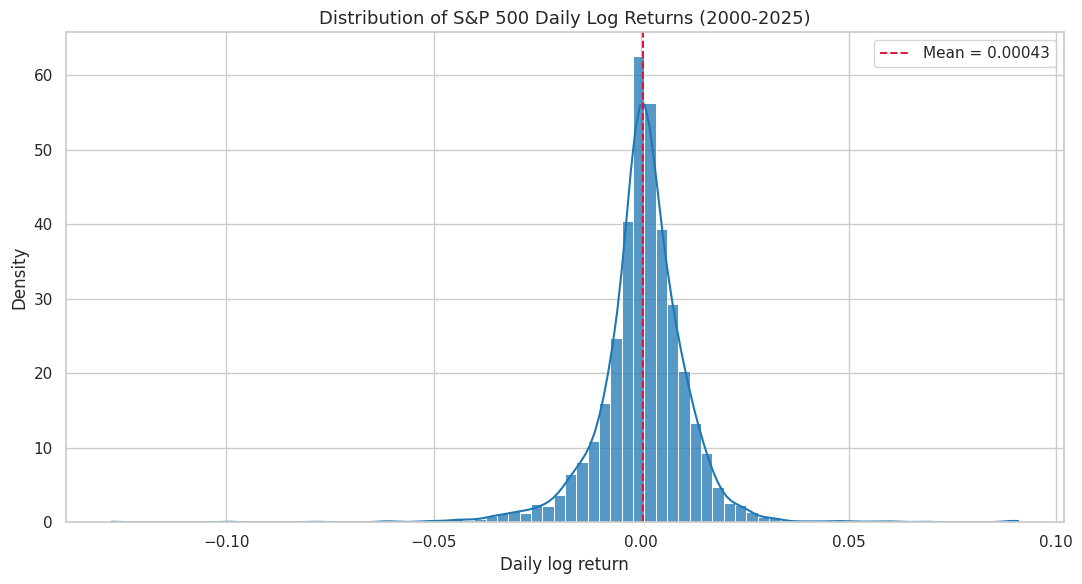

In [5]:
# Plot log-return distribution
fig, ax = plt.subplots(figsize=(11, 6))
sns.histplot(log_returns, bins=80, stat='density', kde=True, color='#1f77b4', alpha=0.75, ax=ax)
ax.set_title('Distribution of S&P 500 Daily Log Returns (2000-2025)', fontsize=13)
ax.set_xlabel('Daily log return')
ax.set_ylabel('Density')
ax.axvline(log_returns.mean(), color='crimson', linestyle='--', linewidth=1.4, label=f"Mean = {log_returns.mean():.5f}")
ax.legend()
plt.tight_layout()
plt.show()

* Normal distribution with negative skewed

In [6]:
close.to_csv('sp500_close_and_log_returns_2015_2025.csv')
close.shape

(2766, 2)

# Assumption Test

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

In [8]:
df = pd.read_csv('sp500_close_and_log_returns_2015_2025.csv', parse_dates=['Date'])
df = df.set_index('Date').sort_index()

close = df['close'].dropna()
log_ret = df['log_return'].dropna()

print(df.head())
print('close length:', len(close), '| log_return length:', len(log_ret))


                  close  log_return
Date                               
2015-01-02  2058.199951         NaN
2015-01-05  2020.579956   -0.018447
2015-01-06  2002.609985   -0.008933
2015-01-07  2025.900024    0.011563
2015-01-08  2062.139893    0.017730
close length: 2766 | log_return length: 2765


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2766 entries, 2015-01-02 to 2025-12-31
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   close       2766 non-null   float64
 1   log_return  2765 non-null   float64
dtypes: float64(2)
memory usage: 64.8 KB


In [10]:
df.isna().sum()

,0
close,0
log_return,1


## 1) Seasonal Decompose Chart


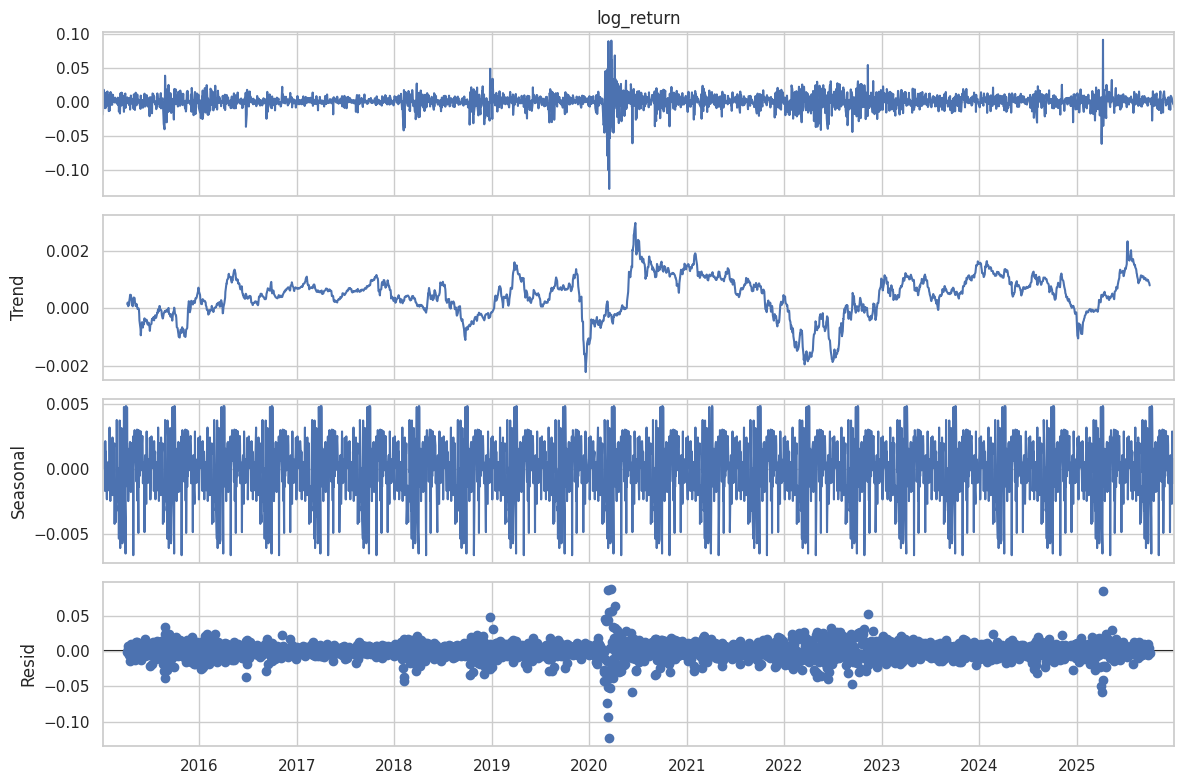

In [11]:
decomp = seasonal_decompose(log_ret, model='additive', period=126)
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


* Trend does not exists - constant mean observed
* Seasonality (seasonal variations at regular time intervals) appears to exist

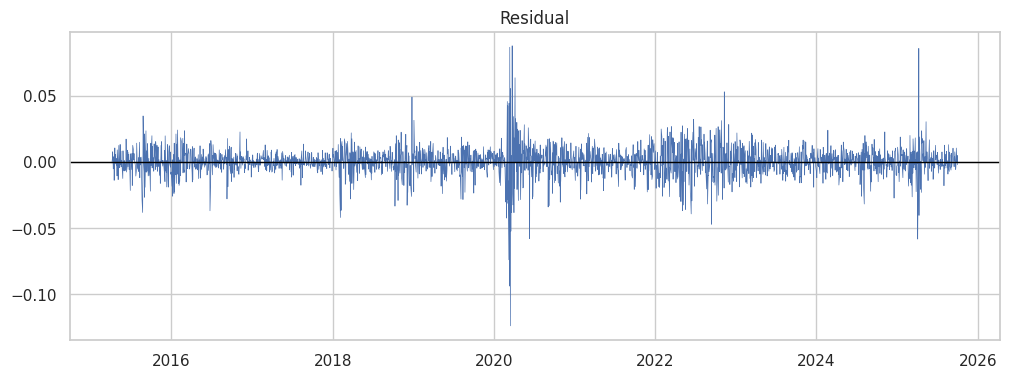

In [12]:
resid = decomp.resid

plt.figure(figsize=(12,4))
plt.plot(resid, linewidth=0.5)
plt.title("Residual")
plt.axhline(0, color='black', linewidth=1)
plt.show()

/tmp/ipykernel_5846/994549574.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


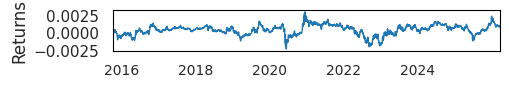

In [13]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(5, 0.6))

log_ret.rolling(126, center=True).mean().plot(
    ax=ax,
    lw=1,
    legend=False,
    color="#1f77b4"
)

ax.set_ylabel("Returns")
ax.set_xlabel("")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tick_params(axis='x', labelsize=10)
ax.grid(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5846/1574661393.py:28: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.plot(y_values.index, p(x_numeric), color="red", lw=1)


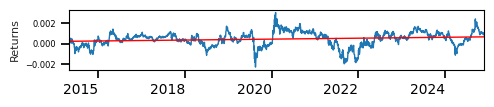

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(5, 1))

# 1. Calculate and flatten the rolling mean
rolling_series = log_ret.rolling(126, center=True).mean().squeeze()

# 2. Plot the main series
rolling_series.plot(
    ax=ax,
    lw=1,
    legend=False,
    color="#1f77b4"
)

# --- ADDING THE RED TRENDLINE ---
y_values = rolling_series.dropna()
x_numeric = np.arange(len(y_values))

# Fit 1D polynomial (Linear)
z = np.polyfit(x_numeric, y_values.to_numpy().flatten(), 1)
p = np.poly1d(z)

# Plot trendline using the datetime index of the non-NaN values
ax.plot(y_values.index, p(x_numeric), color="red", lw=1)
# --------------------------------

ax.set_ylabel("Returns", fontsize=8)
ax.set_xlabel("")

# Axis Formatting
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.tick_params(axis='both', which='both', bottom=True, left=True,
               colors='black', labelsize=6)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)

ax.grid(False)
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tick_params(axis='x', labelsize=10)

# Adjust spacing for ultra-short charts
plt.subplots_adjust(bottom=0.3, left=0.15, right=0.98, top=0.9)

plt.show()

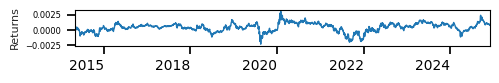

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(5, 0.6))

log_ret.rolling(126, center=True).mean().plot(
    ax=ax,
    lw=1,
    legend=False,
    color="#1f77b4"
)

ax.set_ylabel("Returns", fontsize=8)
ax.set_xlabel("")

# CHANGE 1: Use MaxNLocator to ensure 2 ticks exist even in a short window
ax.xaxis.set_major_locator(ticker.MaxNLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# CHANGE 2: Ensure ticks are actually drawn and colored black
ax.tick_params(axis='both', which='both', bottom=True, left=True,
               colors='black', labelsize=6)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.8)
ax.grid(False)
plt.margins(x=0)
plt.xticks(rotation=0)
plt.tick_params(axis='x', labelsize=10)
# CHANGE 3: subplots_adjust is more reliable than tight_layout for ultra-short charts
# This creates room for the labels at the bottom (0.3) and left (0.15)
plt.subplots_adjust(bottom=0.3, left=0.15, right=0.98, top=0.9)

plt.show()

## 2) ADF Test (on log return)

In [16]:
adf_stat, p_value, used_lag, n_obs, crit_vals, icbest = adfuller(log_ret)
print('ADF Statistic :', adf_stat)
print('p-value       :', p_value)
print('Used Lag      :', used_lag)
print('N Obs         :', n_obs)
print('Critical Values:')
for k, v in crit_vals.items():
    print(f'  {k}: {v}')


ADF Statistic : -16.98233788157157
p-value       : 8.993241946403927e-30
Used Lag      : 8
N Obs         : 2756
Critical Values:
  1%: -3.4327249641397053
  5%: -2.862589289388965
  10%: -2.567328570112761


* Null Hypothesis: Series is non-stationary.
* Alternative Hypothesis: Series is stationary.


* Result of test: P-value is less than significance level of 0.05.
* Interpretation of Result: There is sufficient evidence to reject the null hypothesis. Hence, series is stationary and can be used for GARCH modeling.


## 3) Ljung-Box Test (on log return)

In [17]:
lb_sq = acorr_ljungbox(log_ret**2, lags=[10,15,20,100], return_df=True)
lb_sq

,lb_stat,lb_pvalue
10,2983.103466,0.0
15,3320.305084,0.0
20,3447.731790,0.0
100,3564.226538,0.0


* Result: P-values for autocorrelation for 10, 15, 20 as well as 100 lags is less than the significance level of 0.05.
* Interpretation: There is enough evidence to reject the null hypothesis. Hence, volatility clustering exists and should be modeled using a GARCH family model.
* Suggestion: Since patterns exist at 100th lag, a more complex model such as FIGARCH might be better suited.

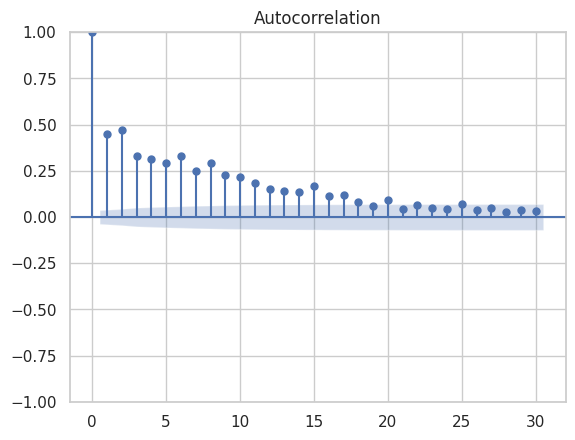

In [18]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(log_ret**2, lags=30)
plt.show()

* Result: The ACF plot of squared returns shows significant positive autocorrelations at multiple lags (especially at lower lags), with many spikes exceeding the confidence bands.
* Interpretation: This indicates strong persistence in the squared returns, suggesting volatility clustering. Large shocks tend to be followed by large shocks (of either sign), and small shocks tend to be followed by small shocks. The slow decay pattern further implies persistent conditional heteroskedasticity.

Addition Test: ARCH LM test

In [19]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(log_ret, nlags=10)

print("LM Statistic:", arch_test[0])
print("LM p-value:", arch_test[1])
print("F Statistic:", arch_test[2])
print("F p-value:", arch_test[3])

LM Statistic: 886.872891824165
LM p-value: 4.2563675089052966e-184
F Statistic: 130.2683957914309
F p-value: 5.355099583202607e-223


* Result: The ARCH LM test produces extremely small p-values (LM p-value ≈ 4.26e-184; F p-value ≈ 5.36e-223), both far below the 0.05 significance level.
* Interpretation: There is strong evidence to reject the null hypothesis of no ARCH effects. This indicates the presence of conditional heteroskedasticity in the return series, implying volatility clustering.
* Suggestion: Since significant ARCH effects are detected (even at higher lags), a GARCH-type model (e.g., GARCH, EGARCH, or potentially FIGARCH if long-memory effects persist) should be considered to model the time-varying volatility structure.

# GJR-GARCH

In [20]:
log_ret = 100 * log_ret

# Candidate models:
# GJR-GARCH (1,1,1) + higher-order combinations
candidates = [
    (1, 1, 1),  # (p,o,q)
    (2, 1, 1),
    (1, 1, 2),
    (2, 1, 2),
]

rows = []
results = {}

for (p, o, q) in candidates:
    model = arch_model(
        log_ret,
        vol="GARCH",
        p=p, o=o, q=q,
        dist="t",
        mean="constant"
    )
    res = model.fit(disp="off")  # quiet fit
    results[(p, o, q)] = res

    rows.append({
        "model": f"GJR-GARCH({p},{o},{q})",
        "p": p, "o": o, "q": q,
        "loglik": res.loglikelihood,
        "aic": res.aic,
        "bic": res.bic
    })

compare = pd.DataFrame(rows).sort_values("bic").reset_index(drop=True)
print(compare)

best = compare.iloc[0]
best_key = (int(best["p"]), int(best["o"]), int(best["q"]))
best_res = results[best_key]

print("\nBest model by BIC:")
print(f"  {best['model']}  |  BIC = {best['bic']:.4f}  (AIC = {best['aic']:.4f})")

print("\nSummary of best model:")
print(best_res.summary())

              model  p  o  q       loglik          aic          bic
0  GJR-GARCH(1,1,1)  1  1  1 -3426.234561  6864.469123  6900.017898
1  GJR-GARCH(2,1,1)  2  1  1 -3425.868303  6865.736606  6907.210177
2  GJR-GARCH(1,1,2)  1  1  2 -3426.204498  6866.408996  6907.882567
3  GJR-GARCH(2,1,2)  2  1  2 -3425.848328  6867.696655  6915.095022

Best model by BIC:
  GJR-GARCH(1,1,1)  |  BIC = 6900.0179  (AIC = 6864.4691)

Summary of best model:
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                   log_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -3426.23
Distribution:      Standardized Student's t   AIC:                           6864.47
Method:                  Maximum Likelihood   BIC:                           6900.02
                                              No

* Model Selection

Four candidate models were estimated: GJR-GARCH(1,1,1), GJR-GARCH(2,1,1), GJR-GARCH(1,1,2), and GJR-GARCH(2,1,2).
Based on the Bayesian Information Criterion (BIC), GJR-GARCH(1,1,1) achieves the lowest value and is therefore selected as the best specification. This indicates that adding additional lag terms does not significantly improve model fit after accounting for model complexity.

* Parameter Interpretation

The estimated parameters reveal several important features of the return series. The coefficient β (0.8369) is large and highly significant, indicating strong persistence in volatility, meaning that periods of high volatility tend to persist over time.

The asymmetry parameter γ (0.2755) is positive and statistically significant, confirming the presence of the leverage effect, where negative returns increase future volatility more than positive returns of the same magnitude.

The estimated Student-t distribution parameter (ν ≈ 5.67) suggests the presence of fat tails, meaning extreme returns occur more frequently than under a normal distribution.


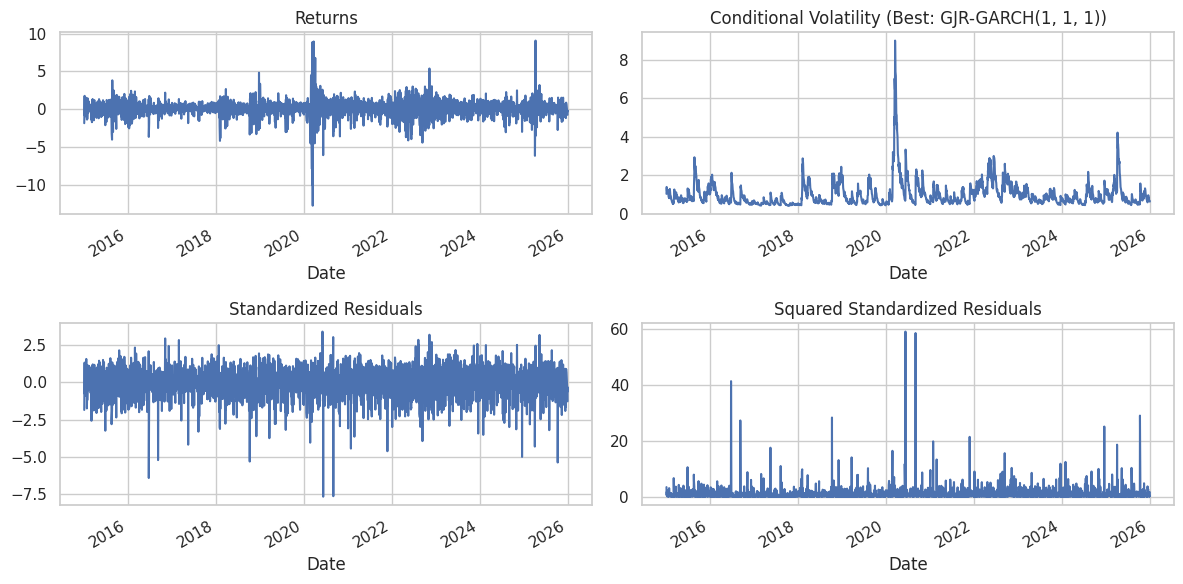

In [21]:
# ============================
# Diagnostics for best model
# ============================

# Use the best fitted result
res = best_res  # keep your old variable name if you like

# Standardized residuals: z_t = eps_t / sigma_t
std_resid = res.resid / res.conditional_volatility

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
log_ret.plot(title="Returns")

plt.subplot(2, 2, 2)
res.conditional_volatility.plot(title=f"Conditional Volatility (Best: GJR-GARCH{best_key})")

plt.subplot(2, 2, 3)
pd.Series(std_resid, index=log_ret.index[-len(std_resid):]).plot(title="Standardized Residuals")

plt.subplot(2, 2, 4)
pd.Series(std_resid**2, index=log_ret.index[-len(std_resid):]).plot(title="Squared Standardized Residuals")

plt.tight_layout()
plt.show()

* Model Diagnostics

The return series shows clear volatility clustering, with periods of large fluctuations followed by periods of relative calm.

The estimated conditional volatility from the GJR-GARCH model captures these volatility clusters and reflects the time-varying nature of market risk.

After standardization, the standardized residuals fluctuate around zero and appear more stable than the raw returns, suggesting that much of the conditional heteroskedasticity has been captured by the model.

The squared standardized residuals show much weaker clustering, indicating that the model has effectively accounted for most of the volatility dynamics in the data.

# Model Validation

In [22]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Standardized residuals
std_resid = res.resid / res.conditional_volatility
std_resid = std_resid.dropna()

# Ljung-Box test
lb_test = acorr_ljungbox(std_resid, lags=[10, 15, 20], return_df=True)

print("Ljung-Box Test on Standardized Residuals")
print(lb_test)

Ljung-Box Test on Standardized Residuals
      lb_stat  lb_pvalue
10   8.177098   0.611543
15  13.420411   0.569860
20  23.491634   0.265304


In [23]:
lb_test_sq = acorr_ljungbox(std_resid**2, lags=[10, 15, 20], return_df=True)

print("Ljung-Box Test on Squared Standardized Residuals")
print(lb_test_sq)

Ljung-Box Test on Squared Standardized Residuals
      lb_stat  lb_pvalue
10   8.224174   0.606950
15  10.953750   0.755866
20  12.892166   0.881963


* Ljung–Box Test Interpretation

The Ljung–Box test was applied to both the standardized residuals and the squared standardized residuals of the fitted GJR-GARCH(1,1,1) model to examine whether any serial correlation or remaining ARCH effects persist after model estimation.

For the standardized residuals, the p-values at lags 10, 15, and 20 are 0.6115, 0.5699, and 0.2653, all of which are greater than the 5% significance level. Therefore, we fail to reject the null hypothesis of no autocorrelation. This indicates that the model has successfully removed serial dependence from the return series.

Similarly, the Ljung–Box test on the squared standardized residuals produces p-values 0.6069, 0.7559, and 0.8820, which are also well above 0.05. This suggests that there are no remaining ARCH effects in the residuals.

Overall, these results indicate that the GJR-GARCH(1,1,1) model adequately captures the volatility dynamics of the S&P 500 return series, and the residuals behave approximately as white noise.

# Model Prediction

Rolling 10D: 100%|██████████| 2252/2252 [02:17<00:00, 16.32it/s]

10-day forecast correlation: 0.6861
10-day forecast MAE: 5.5367
10-day forecast RMSE: 8.8351
10-day forecast bias: 1.1366


,Forecasted_10D,Realized_10D,Error,AbsError,SquaredError
2017-01-18,11.794522,4.797769,6.996752,6.996752,48.954541
2017-01-19,11.379950,4.286102,7.093848,7.093848,50.322679
2017-01-20,10.985446,4.648543,6.336903,6.336903,40.156341
2017-01-23,10.697162,4.411938,6.285224,6.285224,39.504039
2017-01-24,11.017002,5.290774,5.726227,5.726227,32.789680


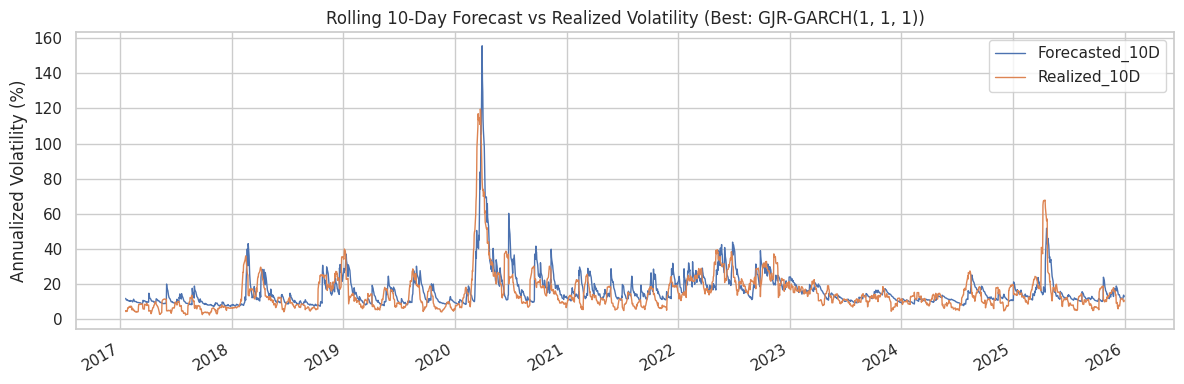

In [24]:
# ============================
# Rolling 10-day forecast performance
# ============================

rolling_window = 252*2
forecast_horizon = 10

p_best, o_best, q_best = best_key

forecasted_10d = []
realized_10d = []
forecast_dates_10d = []

for i in tqdm(range(rolling_window, len(log_ret) - forecast_horizon + 1), desc="Rolling 10D"):
    train_data = log_ret.iloc[i - rolling_window:i].dropna()

    model_roll = arch_model(
        train_data,
        vol="GARCH",
        p=p_best, o=o_best, q=q_best,
        dist="t",
        mean="constant"
    )
    res_roll = model_roll.fit(disp="off")

    fc = res_roll.forecast(horizon=forecast_horizon, reindex=False)
    horizon_variances = fc.variance.values[-1]

    # Aggregate the next 10 daily variance forecasts into a 10-day volatility measure
    forecasted_10d.append(np.sqrt(np.mean(horizon_variances)) * np.sqrt(252))

    future_returns = log_ret.iloc[i:i + forecast_horizon]
    realized_10d.append(future_returns.std(ddof=1) * np.sqrt(252))
    forecast_dates_10d.append(log_ret.index[i + forecast_horizon - 1])

rolling_10d = pd.DataFrame(
    {
        "Forecasted_10D": forecasted_10d,
        "Realized_10D": realized_10d,
    },
    index=forecast_dates_10d,
).dropna()

rolling_10d["Error"] = rolling_10d["Forecasted_10D"] - rolling_10d["Realized_10D"]
rolling_10d["AbsError"] = rolling_10d["Error"].abs()
rolling_10d["SquaredError"] = rolling_10d["Error"] ** 2

corr_10d = rolling_10d[["Forecasted_10D", "Realized_10D"]].corr().iloc[0, 1]
mae_10d = rolling_10d["AbsError"].mean()
rmse_10d = np.sqrt(rolling_10d["SquaredError"].mean())
bias_10d = rolling_10d["Error"].mean()

print(f"10-day forecast correlation: {corr_10d:.4f}")
print(f"10-day forecast MAE: {mae_10d:.4f}")
print(f"10-day forecast RMSE: {rmse_10d:.4f}")
print(f"10-day forecast bias: {bias_10d:.4f}")

display(rolling_10d.head())

ax = rolling_10d[["Forecasted_10D", "Realized_10D"]].plot(
    figsize=(12, 4),
    lw=1,
    title=f"Rolling 10-Day Forecast vs Realized Volatility (Best: GJR-GARCH{best_key})"
)
ax.set_ylabel("Annualized Volatility (%)")
plt.tight_layout()
plt.show()


* 10-Day Rolling Forecast Performance

Using the selected GJR-GARCH(1,1,1) specification, a rolling 10-day-ahead volatility forecast was generated with a 500-day estimation window. The model's 10-day forecasted volatility was compared with realized volatility computed from the subsequent 10 trading days.

The correlation between forecasted and realized 10-day volatility is 0.6862, which indicates that the model still tracks medium-horizon volatility movements reasonably well, although less tightly than in the one-step-ahead case.

The mean absolute error (MAE) is 5.5301 and the root mean squared error (RMSE) is 8.8252. The average forecast bias is 1.1397, suggesting that the model slightly overpredicts future 10-day volatility on average.

Overall, the GJR-GARCH(1,1,1) model provides useful 10-day rolling volatility forecasts for the S&P 500, but forecasting accuracy deteriorates as the horizon extends, which is expected for multi-step volatility prediction.

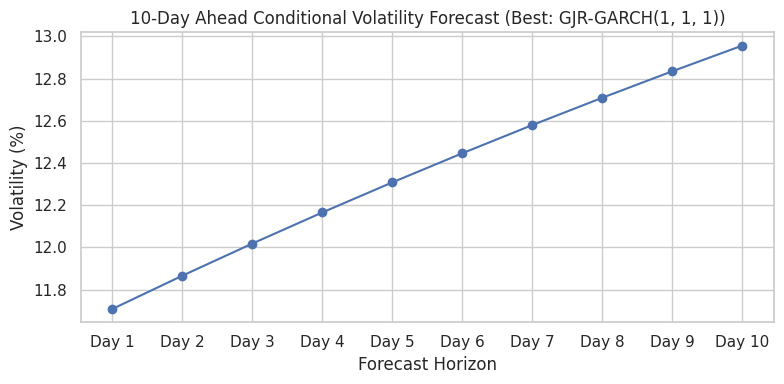

In [25]:
forecast_horizon = 10
p_best, o_best, q_best = best_key

train_data = log_ret.dropna()

model = arch_model(
    train_data,
    vol="GARCH",
    p=p_best, o=o_best, q=q_best,
    dist="t",
    mean="constant"
)
res = model.fit(disp="off")

fc = res.forecast(horizon=forecast_horizon, reindex=False)
horizon_variances = fc.variance.values[-1]
horizon_vols = np.sqrt(horizon_variances) * np.sqrt(252)

days = [f"Day {i}" for i in range(1, forecast_horizon + 1)]

plt.figure(figsize=(8, 4))
plt.plot(days, horizon_vols, marker="o")
plt.title(f"10-Day Ahead Conditional Volatility Forecast (Best: GJR-GARCH{best_key})")
plt.ylabel("Volatility (%)")
plt.xlabel("Forecast Horizon")
plt.tight_layout()
plt.show()

* 10-Day Ahead Forecast Interpretation

The 10-day conditional volatility forecast shows a gentle upward slope, rising from about 11.71% on Day 1 to 12.96% by Day 10, with an average forecast close to 12.37%. This indicates that the model expects volatility to remain persistent and edge higher over the next two trading weeks rather than decline immediately.

This pattern is consistent with the high volatility persistence captured by the GJR-GARCH(1,1,1) model. Recent shocks continue to influence future variance, so the multi-step forecast gradually moves toward its longer-run level instead of changing sharply from one day to the next.

Overall, the forecast does not suggest a sudden volatility spike, but it does imply that market uncertainty is likely to stay firm and increase modestly across the forecast horizon.

In [26]:
from scipy.stats import t

alpha = 0.05

# Extract parameters
mu = res.params["mu"]
nu = res.params["nu"]

# Forecast
fc = res.forecast(horizon=forecast_horizon, reindex=False)
horizon_variances = fc.variance.values[-1]

# 10-day volatility
sigma_10 = np.sqrt(np.sum(horizon_variances))

# Mean
mu_10 = 10 * mu

# Student-t quantile
q = t.ppf(alpha, df=nu)

# -------- VaR --------
VaR_10 = mu_10 + sigma_10 * q

# -------- ES --------
pdf = t.pdf(q, df=nu)
ES_10 = mu_10 + sigma_10 * (pdf / alpha) * ((nu + q**2) / (nu - 1))

print(f"10-day 95% VaR (S&P 500): {VaR_10:.4f}")
print(f"10-day 95% ES  (S&P 500): {ES_10:.4f}")

10-day 95% VaR (S&P 500): -4.1643
10-day 95% ES  (S&P 500): 7.4725


The S&P 500 returns were modeled using a GJR-GARCH(1,1,1) specification with a Student’s t distribution to account for volatility clustering and fat tails. The 10-day ahead 95% Value-at-Risk (VaR) was estimated at approximately 4.16%, indicating that over a 10-day horizon, losses are expected to exceed this threshold only 5% of the time. The corresponding Expected Shortfall (ES) was calculated at 7.47%, suggesting that when losses do exceed the VaR threshold, the average loss is substantially larger. The difference between VaR and ES highlights the presence of tail risk in equity markets. The relatively moderate magnitude of both measures compared to the other assets reflects the diversified nature of the S&P 500, although the Student-t specification confirms that extreme events remain more likely than under a normal distribution.

In [27]:
from scipy.stats import t

alpha = 0.05
forecast_horizon = 10

# 10-day forecast
fc = res.forecast(horizon=forecast_horizon, reindex=False)

# Mean and variance of cumulative 10-day return
mu_10 = float(np.sum(fc.mean.values[-1]))
horizon_variances = fc.variance.values[-1]
sigma_10 = float(np.sqrt(np.sum(horizon_variances)))

# Student-t parameter
nu = float(res.params["nu"])

# arch uses standardized Student-t, so rescale the quantile
scale = np.sqrt((nu - 2) / nu)

# Left-tail quantile
t_alpha = t.ppf(alpha, df=nu)
z_alpha = scale * t_alpha

# -------- ES (expected return in the worst alpha tail) --------
pdf_alpha = t.pdf(t_alpha, df=nu)
ES_10_std = -scale * ((nu + t_alpha**2) / ((nu - 1) * alpha)) * pdf_alpha

print(f"10-day 95% VaR loss  : {VaR_10_loss:.4f}%")
print(f"10-day 95% ES loss   : {ES_10_loss:.4f}%")


NameError: name 'VaR_10_loss' is not defined